<a id="Snowflake_Feature_Store_L2"></a>
# Snowflake Feature Store Part 2



<a id="topics"></a>
### 1.1 Topics in this lesson


1. [Snowflake Feature Store](#Snowflake_Feature_Store_L2)
    1. [Topics in this Lesson](#topics)
    1. [Initial setup](#Initial_setup)
    1. [Setting up the feature store](#setup_feature_store)
    1. [Model Registry](#model_registry)   
    1. [Create FeatureStore Client](#FeatureStore_Client)  
    1. [Create and register a new Entity](#register_a_new_Entity)  

1. [Creating the feature engineering pipelines](#create_Pipelines)  
    1. [FeatureView Creation](#FeatureView_Creation)  
    1. [Retrieving features](#Retrieving_features)  
    1. [Datasets](#Datasets)  
1. [Fit a Snowpark-ML Kmeans Model](#Snowpark_ML_Kmeans)  
    1. [Check the model clusters](#model_clusters)  
    

<a id="Initial_setup"></a>
### 1.2 Initial setup



In [1]:
# Run utils notebook
# %run ../../utils/ds_utils_python.ipynb

# Connect to Snowflake and create a Session object named session
from snowflake.snowpark import Session

session = Session.builder.configs({
      "account":   "ES10286-ML_ENTERPRISE",
      "user":      "RKIRK",
      "password":  "8d!upvFs2#BDDB5JQ*7",
      "role":      "DEV_RK_FINANCE_SYSADMIN",
      "warehouse": "DAFT_WH",
      "database":  "RK_SANDPIT",
      "schema":    "DAFT_SCHEMA"
  }).create()

In [2]:
from IPython.core.magic import register_cell_magic

@register_cell_magic
def snowpark_sql(line, cell):
    """
    Usage: %%snowpark_sql [variable_name]
    Runs the cell body as SQL via the Snowpark session,
    and stores the result as a Snowpark DataFrame.
    """
    var_name = line.strip() or "_snowpark_result"
    df = session.sql(cell)
    get_ipython().user_ns[var_name] = df
    return df

In [3]:
# Python packages
import os
from os import listdir
from os.path import isfile, join
import time
import json
import timeit
import numpy as np
import pandas as pd
import datetime
import ast      
from datetime import date, datetime 
from decimal import Decimal

# Snowpark
from snowflake.snowpark import Session, DataFrame, Window, WindowSpec

import snowflake.snowpark.functions as F
import snowflake.snowpark.types as T
from snowflake.snowpark.version import VERSION

# Snowflake Feature Store
from snowflake.ml.feature_store import (
    FeatureStore,
    FeatureView,
    Entity,
    CreationMode)

# Snowflake Model Registry
from snowflake.ml.registry import Registry
from snowflake.ml.utils import connection_params
from snowflake.ml._internal.utils import  identifier  

#### Specific Packages
from snowflake.ml.modeling.pipeline import Pipeline as sml_Pipeline
from snowflake.ml.modeling.preprocessing import MinMaxScaler as sml_MinMaxScaler
from snowflake.ml.modeling.cluster import KMeans as sml_KMeans

/Users/richardkirk/SourceCode/snowflake-datasciencelabs-jupyter/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id="setup_feature_store"></a>
### 1.3 Setting up the feature store

With our database and database objects created, we can now get started on Feature Engineering and Model Training. 

In [4]:
# Let us set the defaults again:

# Create an empty DataFrame for reflecting upon our context items
context_df = session.create_dataframe([""]).to_df("")

# Retrieve the current username
from snowflake.snowpark.functions import current_user
username = (str(context_df
    .select(current_user())
    .collect()[0][0]
   )
)
print(f"The current user is: {username}")

# Roles
ds_role                 = 'DS_ROLE'


# Database
segmentation_database_base       = f'SEGMENTATION' 
segmentation_database        = f'{segmentation_database_base}_LIVE' 


# Schemas
segmentation_training_schema     = 'TRAINING'
segmentation_scoring_schema      = 'SCORING'
segmentation_serving_schema      = 'SERVING'

# Set  Environment
snowflake_environment = session.sql('SELECT current_user(), current_version()').collect()
session.sql(f'''use role {ds_role}''').collect()
session.sql(f'''use database {segmentation_database}''').collect()
session.sql(f'''use schema {segmentation_training_schema}''').collect()

# Create a Warehouse
warehouse_sz = 'MEDIUM'
warehouse_env = f'SEGMENTATION_WH'
session.sql(f'''use warehouse {warehouse_env}''').collect()
session.sql(f'''alter warehouse {warehouse_env} set warehouse_size = {warehouse_sz}''').collect()


# Current Environment Details
print('\nConnection Established with the following parameters:')
print(f'User                        : {snowflake_environment[0][0]}')
print(f'Role                        : {session.get_current_role()}')
print(f'Database                    : {session.get_current_database()}')
print(f'Schema                      : {session.get_current_schema()}')
print(f'Warehouse                   : {session.get_current_warehouse()}')
print(f'Snowflake version           : {snowflake_environment[0][1]}')

The current user is: RKIRK

Connection Established with the following parameters:
User                        : RKIRK
Role                        : "DS_ROLE"
Database                    : "SEGMENTATION_LIVE"
Schema                      : "TRAINING"
Warehouse                   : "SEGMENTATION_WH"
Snowflake version           : 10.17.102


<a id="model_registry"></a>
### 1.4 Model Registry
As part of this demo, we will use a model registry. More about the Model Registry later in this course.

In [5]:
# Create a model registry
session.sql('CREATE SCHEMA IF NOT EXISTS _MODEL_REGISTRY').collect()

mr = Registry(session=session, database_name= segmentation_database, schema_name='_MODEL_REGISTRY')

<a id="FeatureStore_Client"></a>
### 1.5 Create FeatureStore Client

Let's also create a feature store client. This will create a new schema in the selected database. 

We can pass in an existing database name, or a new database will be created upon the feature store initialization.

Our Feature Store is called **TRAINING_FEATURE_STORE**, so after creation you should be able to find a new schema with the same name.

This schema contains all the objects created through your interactions with the Python Feature Store API. Database objects are tagged with Feature Store related tags to denote that they are part of the Feature Store. These tags are used by Snowsight to discover and present Feature Store objects. The two main other types of database objects that you will see being created are Dynamic Tables and Views. We will describe these in more detail later in this section.


In [6]:
# Set the Schema
segmentation_schema = segmentation_training_schema

fs = (FeatureStore(
        session  = session, 
        database = segmentation_database, 
        name     = f"""_{segmentation_schema}_FEATURE_STORE""", 
        default_warehouse = warehouse_env, 
        creation_mode = CreationMode.CREATE_IF_NOT_EXIST)
     )


# Create fully qualified names of tables
customer_tbl                     = '.'.join([segmentation_database, segmentation_schema,'CUSTOMER'])
line_item_tbl                    = '.'.join([segmentation_database, segmentation_schema,'LINEITEM'])
order_tbl                        = '.'.join([segmentation_database, segmentation_schema,'ORDERS'])
order_returns_tbl                = '.'.join([segmentation_database, segmentation_schema,'ORDER_RETURNS'])

# Snowpark Dataframe
customer_sdf               = session.table(customer_tbl)
line_item_sdf              = session.table(line_item_tbl)
order_sdf                  = session.table(order_tbl)
order_returns_sdf          = session.table(order_returns_tbl)

# Row Counts
print(f'''\nTABLE ROW_COUNTS IN {segmentation_schema}''')
print(customer_tbl, customer_sdf.count())
print(line_item_tbl, line_item_sdf.count())
print(order_tbl, order_sdf.count())
print(order_returns_tbl, order_returns_sdf.count())


TABLE ROW_COUNTS IN TRAINING
SEGMENTATION_LIVE.TRAINING.CUSTOMER 70710
SEGMENTATION_LIVE.TRAINING.LINEITEM 23026666
SEGMENTATION_LIVE.TRAINING.ORDERS 3676955
SEGMENTATION_LIVE.TRAINING.ORDER_RETURNS 1331620


The diagram below depicts the Feature Store information-architecture and how objects in the Python API relate to Database objects.


<img src="../../images/feature_store_information_architecture.png" alt="feature_store_information_architecture" style="width:90%;display:block;margin-left:10%;" />

<a id="register_a_new_Entity"></a>
### 1.6 Create and register a new Entity

Now we have our Feature Store created we can create the Entity that we will be using for this use case. Entities are the underlying object that features and feature views are associated with. They encapsulate the join keys used for feature lookups


We will create an Entity called *CUSTOMER* and register it with the feature store.

You can retrieve the active Entities in the feature store with list_entities() API.

In [7]:
# Let's create the customer entity
customer_entity = Entity(name="CUSTOMER", join_keys=["O_CUSTOMER_SK"],desc="Primary Key for CUSTOMER")
fs.register_entity(customer_entity)


fs.list_entities().show()

/Users/richardkirk/SourceCode/snowflake-datasciencelabs-jupyter/venv/lib/python3.12/site-packages/snowflake/ml/feature_store/feature_store.py:315: UserWarning: Entity CUSTOMER already exists. Skip registration.
  return f(self, *args, **kargs)


---------------------------------------------------------------------
|"NAME"    |"JOIN_KEYS"        |"DESC"                    |"OWNER"  |
---------------------------------------------------------------------
|CUSTOMER  |["O_CUSTOMER_SK"]  |Primary Key for CUSTOMER  |DS_ROLE  |
---------------------------------------------------------------------



The code above defines an instance of the Feature Store entity. The register_entity method creates the object in the database. Entities are created as database tags.

Mynote: Seems that some of these methods create tags;
```sql
SHOW TAGS IN SCHEMA SEGMENTATION_LIVE._TRAINING_FEATURE_STORE;
```
- SNOWML_FEATURE_STORE_ENTITY_CUSTOMER
- SNOWML_FEATURE_STORE_OBJECT
- SNOWML_FEATURE_VIEW_METADATA


<a id="create_Pipelines"></a>
## 2. Creating the feature engineering pipelines

Our Feature engineering pipelines are defined using Snowpark dataframes (or SQL expressions).

We will 
- take the source tables as dataframe objects
- join them together
- performing some data-cleansing by replacing NA's with default values. 

It will return a dataframe as its output.

Then we take the dataframe output and 
- perform aggregation on it to derive some features that will be used in our segmentation model. 

It again returns a dataframe as output, which we will use to provide the feature-pipeline definition within our FeatureView.

In this way we can build up a complex pipeline step-by-step and use it to derive a FeatureView, that will be maintained as a pipeline in Snowflake.


In [ ]:
# MyNote: Not needed replaced by my SQL version - see later cell

# Default replacement values for Null dates and decimal types
epoch_dt = date(year=1970, month=1, day=1)
decimal_zero = Decimal('0.0')

order_data =order_sdf
lineitem_data =line_item_sdf 
order_returns_data = order_returns_sdf

# Merge three dataframes
raw_data =  (lineitem_data
    .join(
        order_returns_data,
        (lineitem_data["LI_ORDER_ID"] == order_returns_data["OR_ORDER_ID"]) &
        (lineitem_data["LI_PRODUCT_ID"] == order_returns_data["OR_PRODUCT_ID"]),
        "left") \
    .join(
        order_data,
        order_returns_data["OR_ORDER_ID"] == order_data["O_ORDER_ID"],
        "inner") \
    .select(   "O_ORDER_ID",  "O_CUSTOMER_SK", "ORDER_TS", "WEEKDAY", "ORDER_DATE", "LI_PRODUCT_ID", "PRICE", "QUANTITY", "OR_RETURN_QUANTITY") \
    .fillna({ "O_ORDER_ID": 0, "O_CUSTOMER_SK": 0, "ORDER_DATE": epoch_dt, "PRICE": decimal_zero, "QUANTITY": 0, "OR_RETURN_QUANTITY": 0 })
            )

raw_data = raw_data[['O_ORDER_ID', 'O_CUSTOMER_SK', 'ORDER_DATE', 'LI_PRODUCT_ID', 'PRICE', 'QUANTITY', 'OR_RETURN_QUANTITY']]

MyNote: storing data in raw_data variable to then be used in subsequent code block is apparently the equivalent of just defining the query as a CTE or view and then using it; snowpark is not actually fetching or moving any data, instead just defining a query for later reference.

In [ ]:
raw_data.show()

Create & Run Preprocessing Function

In [ ]:
# MyNote: Not needed replaced by my SQL version - see later cell
# MyNote: This hangs, but the equivalent SQL runs in a few seconds directly on Snowsight, and works in my SQL session query verison for preprocessed_data_RK - see cell below this one 

# Calculate INVOICE_YEAR, ROW_PRICE and RETURN_ROW_PRICE
data = raw_data.with_columns(["INVOICE_YEAR",  "ROW_PRICE",  "RETURN_ROW_PRICE" ]
                        ,[ F.year(raw_data["ORDER_DATE"]),  raw_data["QUANTITY"] * raw_data["PRICE"],  raw_data["OR_RETURN_QUANTITY"] * raw_data["PRICE"]] )

# Generate Customer/Order level features : total-price, total-return-price, year of first order last-order-date
groups = data.groupBy("O_CUSTOMER_SK", "O_ORDER_ID").agg(
    F.sum(F.col("ROW_PRICE")).alias("ROW_PRICE"),
    F.sum(F.col("RETURN_ROW_PRICE")).alias("RETURN_ROW_PRICE"),
    F.min(F.col("INVOICE_YEAR")).alias("INVOICE_YEAR"),
    F.max(F.col("ORDER_DATE")).alias("LATEST_ORDER_DATE"))

# Calculate price RETURN RATIO per Customer
groups = groups.withColumn("RATIO", groups["RETURN_ROW_PRICE"] / groups["ROW_PRICE"])
ratio = groups.groupBy("O_CUSTOMER_SK").agg(F.avg(F.col("RATIO")).cast(T.FloatType()).alias("RETURN_RATIO"), 
                                            F.max(F.col("LATEST_ORDER_DATE")).alias("LATEST_ORDER_DATE")
                                            )

# Calculate average annual shopping FREQUENCY 
frequency_groups = groups.groupBy("O_CUSTOMER_SK", "INVOICE_YEAR").agg(F.count(F.col("O_ORDER_ID")).cast(T.FloatType()).alias("FREQUENCY"))
frequency = frequency_groups.groupBy("O_CUSTOMER_SK").agg(F.avg(F.col("FREQUENCY")).alias("FREQUENCY"))

# Merge FREQUENCY and RETURN_RATIO
preprocessed_data = frequency.join(ratio, on="O_CUSTOMER_SK")



In [ ]:
# i was not able to run this, as the step above to create it hangs
preprocessed_data.show()

### MyNote: Replace dataframe from snowpark methods with direct SQL version
The below replaces the above previous 2 code blocks<br>
NB Seems have to fully qualify the tables e.g. SEGMENTATION_LIVE.TRAINING.LINEITEM for it to work when passed to FeatureView() later

In [7]:
%%snowpark_sql preprocessed_data_RK

with cte_raw_data as (
--block 1

  SELECT
      COALESCE(o.O_ORDER_ID, 0)          AS O_ORDER_ID,
      COALESCE(o.O_CUSTOMER_SK, 0)       AS O_CUSTOMER_SK,
      COALESCE(o.ORDER_DATE, '1970-01-01') AS ORDER_DATE,
      l.LI_PRODUCT_ID,
      COALESCE(l.PRICE, 0.0)             AS PRICE,
      COALESCE(l.QUANTITY, 0)            AS QUANTITY,
      COALESCE(r.OR_RETURN_QUANTITY, 0)  AS OR_RETURN_QUANTITY
  FROM SEGMENTATION_LIVE.TRAINING.LINEITEM l
  LEFT JOIN SEGMENTATION_LIVE.TRAINING.ORDER_RETURNS r
      ON  l.LI_ORDER_ID  = r.OR_ORDER_ID
      AND l.LI_PRODUCT_ID = r.OR_PRODUCT_ID
  INNER JOIN SEGMENTATION_LIVE.TRAINING.ORDERS o
      ON r.OR_ORDER_ID = o.O_ORDER_ID
)

--block 2 from here
, enriched AS (
      SELECT *,
          YEAR(ORDER_DATE)           AS INVOICE_YEAR,
          QUANTITY * PRICE           AS ROW_PRICE,
          OR_RETURN_QUANTITY * PRICE AS RETURN_ROW_PRICE
      FROM cte_raw_data
  )
  
,order_groups AS (
      SELECT O_CUSTOMER_SK, O_ORDER_ID,
          SUM(ROW_PRICE)          AS ROW_PRICE,
          SUM(RETURN_ROW_PRICE)   AS RETURN_ROW_PRICE,
          MIN(INVOICE_YEAR)       AS INVOICE_YEAR,
          MAX(ORDER_DATE)         AS LATEST_ORDER_DATE
      FROM enriched
      GROUP BY O_CUSTOMER_SK, O_ORDER_ID
  ),
  ratio AS (
      SELECT O_CUSTOMER_SK,
          AVG(RETURN_ROW_PRICE / NULLIF(ROW_PRICE, 0))::FLOAT AS RETURN_RATIO,
          MAX(LATEST_ORDER_DATE)                              AS LATEST_ORDER_DATE
      FROM order_groups
      GROUP BY O_CUSTOMER_SK
  ),
  freq_by_year AS (
      SELECT O_CUSTOMER_SK, INVOICE_YEAR,
          COUNT(O_ORDER_ID)::FLOAT AS FREQUENCY
      FROM order_groups
      GROUP BY O_CUSTOMER_SK, INVOICE_YEAR
  ),
  frequency AS (
      SELECT O_CUSTOMER_SK, AVG(FREQUENCY) AS FREQUENCY
      FROM freq_by_year
      GROUP BY O_CUSTOMER_SK
  )
  SELECT f.O_CUSTOMER_SK, f.FREQUENCY, r.RETURN_RATIO, r.LATEST_ORDER_DATE
  FROM frequency f
  JOIN ratio r ON f.O_CUSTOMER_SK = r.O_CUSTOMER_SK

In [9]:
preprocessed_data_RK.show()

------------------------------------------------------------------------
|"O_CUSTOMER_SK"  |"FREQUENCY"  |"RETURN_RATIO"  |"LATEST_ORDER_DATE"  |
------------------------------------------------------------------------
|17890            |1.0          |0.74857534      |2024-08-13           |
|43127            |1.0          |0.75            |2023-04-16           |
|67049            |1.0          |0.71276386      |2024-08-23           |
|29106            |1.0          |0.97888889      |2023-09-17           |
|35767            |1.0          |0.65420363      |2023-07-22           |
|772              |1.0          |0.84473892      |2024-09-29           |
|60124            |1.0          |0.67163716      |2025-01-03           |
|38168            |1.0          |0.56707558      |2024-11-11           |
|36456            |1.0          |0.50860135      |2023-03-08           |
|46289            |1.0          |0.76797785      |2024-04-22           |
---------------------------------------------------

<a id="FeatureView_Creation"></a>
### 2.1 FeatureView Creation
We will use the `preprocessed_data` dataframe that we defined in the prior step for the FeatureView we are creating. The FeatureView will create a Dynamic Table in our Feature Store schema. We could use the dataframe directly within the definition of the FeatureView. 


> **&#128221; Note:** This query might return a warning. This is because the query for the dynamic table is seen as complex. By default a dynamic table will then do a `FULL` refresh instead of `INCREMENTAL`

**So now we have created our first FeatureView!**

Same as with the Entity creation above, here is a two step process.

First we create the python instance, and then we register the instance to create an object in the database. 

We provide the feature view name, version, description, and individual descriptions for each feature. We can create new versions of a Feature as it evolves, for example if the definition of some of the Features within change. A created a version is immutable, unless a forced replacement is needed and invoked via overwrite = True.

**MyNotes on below code block: Snowpark vs pure SQL replacement**
This part does need to be snowpark and cannot be replaced with SQL
- The Feature Store API itself (register_feature_view, generate_dataset, retrieve_feature_values) — genuinely requires Snowpark; this is where the library earns its place
- However the query that backs the feature view preprocessed_data can be pure SQL

In [8]:

# Define descriptions for the FeatureView's Features.  These will be added as comments to the database object
preprocess_features_desc = {  "FREQUENCY":"Average yearly order frequency",
                              "RETURN_RATIO":"Average of, Per Order Returns Ratio.  Per order returns ratio : total returns value / total order value" }

fv_name    = "FV_PREPROCESS"
fv_version = "V_1"

try:
   # If FeatureView already exists just return the reference to it
   fv_preprocessing = fs.get_feature_view(name=fv_name,version=fv_version)
except:
   # Create the FeatureView instance
   fv_preprocessing_instance = FeatureView(
      name=fv_name, 
      entities=[customer_entity], # We add the Entity here. This allows the relationship, and join keys, available in the Feature View to be defined.
      feature_df=preprocessed_data_RK,      # Use my version - generated by clean SQL instead of messy Snowpark code version preprocessed_data  
      timestamp_col="LATEST_ORDER_DATE",
      refresh_freq="60 minute",            # Optional refresh_freq creates FeatureView as Dynamic Table, else created as View.
      desc="Features to support Segmentation").attach_feature_desc(preprocess_features_desc)

   # Register the FeatureView instance.  Creates  object in Snowflake
   fv_preprocessing = fs.register_feature_view(
      feature_view=fv_preprocessing_instance, 
      version=fv_version, 
      block=True
   )
   print(f"Feature View : {fv_name}_{fv_version} created")   
else:
   print(f"Feature View : {fv_name}_{fv_version} already created")
finally:
   fs.list_feature_views().show(2)



Feature View : FV_PREPROCESS_V_1 already created
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"NAME"         |"VERSION"  |"DATABASE_NAME"    |"SCHEMA_NAME"            |"CREATED_ON"                |"OWNER"  |"DESC"                            |"ENTITIES"    |"REFRESH_FREQ"  |"REFRESH_MODE"  |"SCHEDULING_STATE"  |"WAREHOUSE"      |"CLUSTER_BY"                            |"ONLINE_CONFIG"                                     |"STORAGE_CONFIG"         |"STREAM_CONFIG"  |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

MyNote: The above register_feature_view() call creates this dynamic view:
<img src="../../images/my-images/register_feature_view-dynamic-table.png" alt="tables-for-features" style="width:25%;display:block;margin-left:10%;" />

Remember we have created incrementing data sources? 

Well, as we specified a refresh frequency, we can observe this incremental processing being applied to the table. We do this using Snowsight's Dynamic Table observation feature.

*The Snowsight UI also contains a section supporting Feature Store discovery and observability, which you can check* 

In [9]:

# You can also use the following to retrieve a Feature View instance for use within Python
FV_PREPROCESSING_V_1 = fs.get_feature_view(fv_name, 'V_1')

# and show it's definition. 
# display(FV_PREPROCESSING_V_1.to_df(session).to_pandas()) # MyNote: This throws error, apparently is a bug in snowflake-ml-python library, but this is not needed anyway

In [10]:
# We can look at the FeatureView's contents with
fv_preprocessing.feature_df.show()

------------------------------------------------------------------------
|"O_CUSTOMER_SK"  |"FREQUENCY"  |"RETURN_RATIO"  |"LATEST_ORDER_DATE"  |
------------------------------------------------------------------------
|17890            |1.0          |0.74857534      |2024-08-13           |
|43127            |1.0          |0.75            |2023-04-16           |
|67049            |1.0          |0.71276386      |2024-08-23           |
|29106            |1.0          |0.97888889      |2023-09-17           |
|35767            |1.0          |0.65420363      |2023-07-22           |
|772              |1.0          |0.84473892      |2024-09-29           |
|60124            |1.0          |0.67163716      |2025-01-03           |
|38168            |1.0          |0.56707558      |2024-11-11           |
|36456            |1.0          |0.50860135      |2023-03-08           |
|46289            |1.0          |0.76797785      |2024-04-22           |
---------------------------------------------------

<a id="Retrieving_features"></a>
### 2.2 Retrieving features

Now we have a feature view. And it has data contained within it. 

We can now use this feature view for model training or model inference.


The Feature Store enables feature-values to be retrieved for a given set of Entity-keys, relative to a reference point-in-time. Under the covers, the Feature Store uses the new SQL ASOF join functionality in Snowflake to efficiently retrieve the requested features across the FeatureViews. The Entity-Keys and Timestamps are provided as a dataframe, which we call a Spine. The Spine can be defined using Snowpark Dataframe functionality, or via a SQL expression.

For example, we can create the spine with the following:

In [11]:
# Create Spine
spine_sdf =  fv_preprocessing.feature_df.group_by('O_CUSTOMER_SK').agg( F.max('LATEST_ORDER_DATE').as_('ASOF_DATE'))#.limit(10)

spine_sdf.sort('O_CUSTOMER_SK').show(5)

---------------------------------
|"O_CUSTOMER_SK"  |"ASOF_DATE"  |
---------------------------------
|0                |2025-01-26   |
|1                |2024-10-26   |
|2                |2024-11-17   |
|3                |2025-01-11   |
|4                |2024-08-18   |
---------------------------------



MyNote: Above is doing this:
```sql
 SELECT
      O_CUSTOMER_SK,
      MAX(LATEST_ORDER_DATE) AS ASOF_DATE  
  FROM SEGMENTATION_LIVE._TRAINING_FEATURE_STORE.FV_PREPROCESS$V_1
  GROUP BY O_CUSTOMER_SK
  ```

<a id="Datasets"></a>
### 2.3 Datasets

Next we use the Spine to create a Dataset. Datasets are a new type of data-object in Snowflake that allows immutable datasets that are optimised for Machine Learning to be persisted and read directly into common machine learning frameworks like scikit-learn, Tensorflow and Pytorch. 

We create the Dataset with the following:

In [12]:
# Generate_Dataset
training_dataset = fs.generate_dataset( name = 'TRAINING',
                                        spine_df = spine_sdf, features = [fv_preprocessing], 
                                        spine_timestamp_col = 'ASOF_DATE'
                                        )                                     

# Create a snowpark dataframe reference from the Dataset
training_dataset_sdf = training_dataset.read.to_snowpark_dataframe()

# Display some sample data
training_dataset_sdf.sort('O_CUSTOMER_SK').show(5)

---------------------------------------------------------------------------
|"O_CUSTOMER_SK"  |"ASOF_DATE"  |"FREQUENCY"         |"RETURN_RATIO"      |
---------------------------------------------------------------------------
|0                |2025-01-26   |1.6666666269302368  |0.7006146907806396  |
|1                |2024-10-26   |3.5                 |0.8004919290542603  |
|2                |2024-11-17   |2.5                 |0.6384019255638123  |
|3                |2025-01-11   |2.0                 |0.6914749145507812  |
|4                |2024-08-18   |3.5                 |0.6873698234558105  |
---------------------------------------------------------------------------



MyNote: **A Snowflake Dataset is essentially a versioned, immutable snapshot of a query result, stored efficiently in Snowflake.** The ML framing is largely a positioning/marketing choice.
  
  The underlying capabilities — point-in-time snapshots, versioning, reproducibility, efficient storage — are genuinely useful for many things beyond ML:
  
  - Audit & compliance — immutable snapshots of data at a specific point in time
  - Reproducible reporting — a versioned dataset guarantees the same report can be regenerated later
  - A/B testing — snapshot the population before an experiment starts
  - Data sharing — share a specific frozen version of data with another team
  - Debugging — reproduce exactly what the data looked like when a problem occurred

  The ML-specific additions are relatively thin — mainly the integration with retrieve_feature_values() and the Snowpark ML training APIs. Strip those away and what you have is just a well-engineered versioned table snapshot.
  
 Snowflake has chosen to position it as an ML primitive, but the underlying construct is broadly useful. It's a common pattern in data platforms — label something as "for ML" to give data scientists a clear entry point, even when the mechanism itself is
general purpose.

It seems that it is not possible to create a Dataset using SQL: Snowflake Datasets appear to be primarily a Python API construct — the snowflake.ml.dataset module is the intended interface, but possible this might change in the future.

In [13]:
# We can view it in Pandas as well
training_dataset_sdf.to_pandas()

,O_CUSTOMER_SK,ASOF_DATE,FREQUENCY,RETURN_RATIO
0,20263,2024-08-11,1.5,1.044608
1,70351,2024-11-03,2.5,0.613176
2,56626,2023-12-17,4.0,0.937500
3,38977,2024-11-15,1.0,0.675125
4,69821,2024-10-20,2.0,0.718789
...,...,...,...,...
70310,68968,2025-02-07,3.0,0.689930
70311,46235,2024-03-03,1.0,0.736998
70312,53803,2025-01-31,2.0,0.683255
70313,8944,2024-09-29,1.0,0.785983


In [14]:
#Returns a list of versions
print(training_dataset.list_versions())


print(training_dataset.selected_version)
print(training_dataset.fully_qualified_name)

['2026_05_16_19_10_25', '2026_05_16_19_36_36', '2026_05_17_10_41_02']
DatasetVersion(dataset='SEGMENTATION_LIVE._TRAINING_FEATURE_STORE.TRAINING', version='2026_05_17_10_41_02')
SEGMENTATION_LIVE._TRAINING_FEATURE_STORE.TRAINING


In [18]:
# Get the latest version
training_dataset_latest = training_dataset.list_versions()[-1]

<a id="Snowpark_ML_Kmeans"></a>
## 3. Fit a Snowpark-ML Kmeans Model

So far we have created a new dataset using a Spine and a FeatureView. Now we use the training Dataset we created to fit a Snowpark-ML Kmeans model.

To do so we define our model fitting pipeline as a function that includes some feature pre-processing to scale our input variables using min-max scaling. These transformations need to be applied at model time, as they capture the global state (e.g. minimum and maximum values for columns) of our training sample.




We fit the model and log it to the Model Registry that we created earlier. **We will discuss the model registry in a later lecture.**

### MyNote on train() function below
In this function we are both definining the model and training it:

  Model definition (before .fit()):
  - A pipeline with two steps:
    - MinMaxScaler — scales RETURN_RATIO and FREQUENCY to 0–1 range, outputting RETURN_RATIO_MMS and FREQUENCY_MMS
    - KMeans — clusters customers using those scaled values, outputting a CLUSTER label

 Training (the .fit() call):
  - Executes the pipeline against the actual data, learning the scale parameters (min/max per feature) and the 5 cluster centroids
  
  The returned km4_purchases object contains the fitted model — i.e. it has memorised the min/max values from the scaler and the 5 centroid positions from KMeans. That's what gets passed to mr.log_model() in the next cell to persist it to the Model Registry.

#### The models being used

In an earlier cell we import the models;
```python
from snowflake.ml.modeling.preprocessing import MinMaxScaler as sml_MinMaxScaler
from snowflake.ml.modeling.cluster import KMeans as sml_KMeans
```

These are wrappers around the standard scikit-learn implementations (sklearn.preprocessing.MinMaxScaler and sklearn.cluster.KMeans).

What Snowflake ML adds on top of the scikit-learn originals is:
- Snowpark integration — they accept Snowpark DataFrames as input rather than numpy arrays/pandas DataFrames
- input_cols / output_cols parameters — so you specify columns by name rather than by position
- Distributed execution — .fit() runs via a stored procedure on Snowflake's compute rather than locally

But the actual ML mathematics — the MinMax scaling algorithm and the KMeans algorithm — are exactly scikit-learn's implementations running under the hood. Snowflake ML isn't reimplementing the algorithms, it's wrapping them to work natively within the Snowflake
ecosystem.

#### Using the trained object
The km4_purchases object returned is a "Snowflake ML Pipeline object" and has .predict() method for local inference.
This can contain multiple steps chained together, here there are two steps:
  1. MinMaxScaler — transforms raw features into scaled features
  2. KMeans — takes scaled features and assigns cluster labels

  But you could add more steps, for example:
  - A feature selection step before scaling
  - A dimensionality reduction step (e.g. PCA) between scaling and clustering
  - Multiple scalers for different subsets of columns
  
  The pipeline handles the sequencing automatically — .fit() trains each step in order, and .predict() passes data through each step in order. This is the same Pipeline concept as scikit-learn's sklearn.pipeline.Pipeline, just wrapped for Snowpark.

In steps below when we call mr.log_model(km4_purchases), the Model Registry serialises the pipeline object (including its learned parameters) and stores it on Snowflake. The model registry version object (mv) has mv.run() method that deserialises it server-side and calls the equivalent of .predict() internally, running the inference on Snowflake's compute as a function.


In [15]:
def train(featurevector, num_clusters):
    mms_input_cols = ['RETURN_RATIO', 'FREQUENCY']
    km_input_cols = mms_output_cols =['RETURN_RATIO_MMS', 'FREQUENCY_MMS']    
    km_output_cols = "CLUSTER"
    km4_purchases = sml_Pipeline(
        steps=[ ("MMS",
                    sml_MinMaxScaler(
                        clip=True,
                        input_cols=mms_input_cols,
                        output_cols=mms_output_cols,)),
                ("KM",
                    sml_KMeans(
                        n_clusters=num_clusters,
                        init='k-means++',
                        max_iter=300,
                        n_init=10,
                        random_state=0,
                        input_cols=km_input_cols,
                        output_cols = km_output_cols)),])
    km4_purchases.fit(featurevector.select(mms_input_cols))
    return {'MODEL': km4_purchases}

In [16]:
## Fit the KMeans Model
model_name = "SNOWFLAKEML_KMEANS_MODEL"

num_clusters = 5

# trains and returns the model object
train_result = train(training_dataset_sdf, num_clusters)#

Package 'snowflake-telemetry-python' is not installed in the local environment. Your UDF might not work when the package is installed on the server but not on your local environment.
/Users/richardkirk/SourceCode/snowflake-datasciencelabs-jupyter/venv/lib/python3.12/site-packages/snowflake/ml/model/model_signature.py:74: UserWarning: The sample input has 70315 rows. Using the first 100 rows to define the inputs and outputs of the model and the data types of each. Use `signatures` parameter to specify model inputs and outputs manually if the automatic inference is not correct.
  warnings.warn(
/Users/richardkirk/SourceCode/snowflake-datasciencelabs-jupyter/venv/lib/python3.12/site-packages/snowflake/ml/model/model_signature.py:74: UserWarning: The sample input has 70315 rows. Using the first 100 rows to define the inputs and outputs of the model and the data types of each. Use `signatures` parameter to specify model inputs and outputs manually if the automatic inference is not correct.


MyNote: Originally running the above to train the model resulted in an error; "XGBoost Library (libxgboost.dylib) could not be loaded."<br>
The fix was this:<br>
```
The error is not related to your KMeans code at all. It's a missing system dependency on your Mac.

  snowflake-ml-python tries to import xgboost as part of building the sklearn model spec (even though you're not using XGBoost), and xgboost requires the OpenMP runtime (libomp.dylib) which isn't installed on your machine.
  
  The fix is one command in your terminal:
  
  brew install libomp

  Then restart your Jupyter kernel and re-run the notebook from the session setup cell.
```
after doing that and rerunning the notebook (some bits not required to re run as feature store already created) it then seemed to run

In [21]:
# We log the model. Did I tell you already that we discuss the Model Registry in a later lecture?
model_version = 'V_2'
mv_kmeans = mr.log_model(model= train_result['MODEL'],
                model_name= model_name,
                version_name= model_version,
                comment="KMEANS - CUSTOMER PURCHASE CLUSTERS"
                )

Logging model: creating model manifest...:  33%|███▎      | 2/6 [00:02<00:05,  1.45s/it]  

/Users/richardkirk/SourceCode/snowflake-datasciencelabs-jupyter/venv/lib/python3.12/site-packages/snowflake/ml/registry/_manager/model_parameter_reconciler.py:84: UserWarning: `relax_version` is not set and therefore defaulted to True. Dependency version constraints relaxed from ==x.y.z to >=x.y, <(x+1). To use specific dependency versions for compatibility, reproducibility, etc., set `options={'relax_version': False}` when logging the model.
  reconciled_options = self._reconcile_relax_version(


Model logged successfully.: 100%|██████████| 6/6 [01:08<00:00, 11.43s/it]                          


MyNote: Above results in model appearing here;
<img src="../../images/my-images/model-registered.png" alt="tables-for-features" style="width:20%;display:block;margin-left:10%;" />

In [22]:
# And we show the model
mr.show_models()

,created_on,name,model_type,database_name,schema_name,comment,owner,default_version_name,versions,aliases
0,2026-05-16 10:43:14.594000-07:00,SNOWFLAKEML_KMEANS_MODEL,USER_MODEL,SEGMENTATION_LIVE,_MODEL_REGISTRY,None,DS_ROLE,V_2,"[""V_2""]","{""DEFAULT"":""V_2"",""FIRST"":""V_2"",""LAST"":""V_2""}"


In [23]:
# Get and set default for latest version of the model
m = mr.get_model(model_name)
latest_version = m.show_versions().iloc[-1]['name']
mv = m.version(latest_version)
m.default = latest_version

<a id="model_clusters"></a>
### 3.1 Check the model clusters
Next we will check the model clusters derived from the model. We create an inference Function using the Snowflake Model Registry. This packages our model as a Python function which enables access from Python or directly from SQL. This allows the model to be used directly for prediction within our Feature Engineering pipeline, by creating an inference Feature View.

During this process we would normally check our model against a test dataset, to generate test-scores for the model. Many more sophisticated validation techniques exist, but are beyond the scope of this lecture.

In [24]:
def serve(inference_df, model) -> DataFrame :
    clusters = model.run(inference_df, function_name="predict")    
    return clusters

In [25]:
# Create Spine
inference_spine_sdf =  fv_preprocessing.feature_df.group_by('O_CUSTOMER_SK').agg(F.max('LATEST_ORDER_DATE').as_('ASOF_DATE'))

# Generate_Dataset
inference_dataset_sdf = fs.retrieve_feature_values(spine_df = inference_spine_sdf, features = [fv_preprocessing],  spine_timestamp_col = 'ASOF_DATE' )

start = timeit.default_timer()
inference_result_sdf = serve(inference_dataset_sdf, mv)#
end = timeit.default_timer()
serve_time = end - start
print('serve time:\t', serve_time)

inference_sample_sdf = inference_result_sdf.sample(n = 10000)
inference_sample_sdf.show()

serve time:	 2.869644958002027
-------------------------------------------------------------------------------------------------------------------------------
|"O_CUSTOMER_SK"  |"ASOF_DATE"  |"RETURN_RATIO"  |"FREQUENCY"         |"RETURN_RATIO_MMS"   |"FREQUENCY_MMS"      |"CLUSTER"  |
-------------------------------------------------------------------------------------------------------------------------------
|50098            |2024-07-23   |0.6540275225    |2.0                 |0.25617353739810256  |0.09090909090909091  |3          |
|11125            |2024-09-01   |0.84808997375   |4.0                 |0.3656683641994433   |0.2727272727272727   |4          |
|19136            |2025-01-13   |0.86155912375   |2.6666666666666665  |0.3732679912108087   |0.15151515151515152  |1          |
|28736            |2024-08-14   |0.82076207      |3.0                 |0.35024928612083456  |0.1818181818181818   |1          |
|44654            |2024-01-10   |0.6554625925    |2.0                 |0.

In [27]:
#Getting unique labels
import matplotlib.pyplot as plt

u_labels = inference_sample_sdf.select(F.array_agg(F.col("CLUSTER"), is_distinct = True).alias("U_LABELS")) \
                .select(F.array_sort(F.col("U_LABELS")).cast(T.StringType()).alias("U_LABELS")).collect()[0][0]

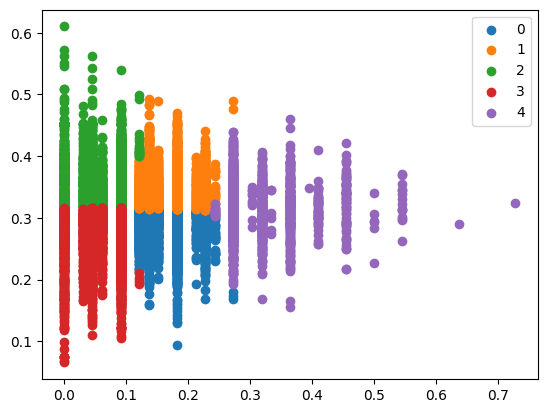

In [28]:
u_labels_lst = json.loads(u_labels)
plt_df = inference_sample_sdf.select(F.col("CLUSTER"), F.col("FREQUENCY_MMS"), F.col("RETURN_RATIO_MMS")).to_pandas()

#plotting the results:
for i in u_labels_lst:
    plt.scatter(plt_df[plt_df['CLUSTER'] == i][['FREQUENCY_MMS']]  , plt_df[plt_df['CLUSTER'] == i][['RETURN_RATIO_MMS']]  , label = i)
plt.legend()
plt.show()

*Above is a simple visualization of our clusters.*

**Now we have a model that is good enough for production and operationalization**

### MyNote : Claude's explanation of the graphed result:<br>

It's a 2D scatter plot of the KMeans clustering results where:

  - X axis — FREQUENCY_MMS: the MinMax-scaled average annual shopping frequency (0–1 scale)
  - Y axis — RETURN_RATIO_MMS: the MinMax-scaled average return ratio (0–1 scale)
  - Each point — one customer
  - Each colour — one of the 5 KMeans clusters (0–4), with a legend

  The MinMax scaling means both axes run from 0 to 1, where 0 is the lowest value in the dataset and 1 is the highest. So a customer in the top-right corner shops frequently AND returns a lot, while bottom-left shops rarely and rarely returns.
  
  The plot lets you visually verify that the 5 clusters are meaningfully separated in this 2D feature space — you'd expect to see 5 distinct colour groupings if the clustering worked well. If the clusters overlap heavily it suggests the model struggled to find clean
  separation with these two features.



MyNotes: Claudes overview of methods that create things on snowflake:
| Operation | What it does on Snowflake |
|---|---|
| `FeatureStore(...)` | Creates the `_TRAINING_FEATURE_STORE` schema |
| `fs.register_entity(...)` | Creates database tags on the account |
| `fs.register_feature_view(..., block=True)` | Creates a Dynamic Table — the most significant deployment; a persistent, auto-refreshing object |
| `fs.generate_dataset(...)` | Materializes an immutable ML dataset in Snowflake storage |
| `mr.log_model(...)` | Persists model artifacts to the `_MODEL_REGISTRY` schema |